# Thư viện và thông tin sinh viên 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

STUDENT_NAME = "Nguyễn Huỳnh Nam Quốc"
STUDENT_ID = "2453089"

print(f"Student: {STUDENT_NAME} - {STUDENT_ID}")

Student: Nguyễn Huỳnh Nam Quốc - 2453089


# Bài 1 — Titanic Dataset

Mục tiêu của phần này là dùng Logistic Regression để dự đoán hành khách có sống sót hay không.  
Em cũng huấn luyện thêm Linear Regression như một mô hình so sánh, nhưng Linear Regression không phải mô hình phù hợp cho bài toán phân loại.

Load Titanic và bỏ cột leakage

In [11]:
df = sns.load_dataset("titanic")

print("Shape ban đầu:", df.shape)
display(df.head())


cols_to_drop = [
    "alive",       
    "who",
    "adult_male",
    "class",
    "deck",
    "embark_town",
    "alone"
]

cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df = df.drop(columns=cols_to_drop)

print("Shape sau khi bỏ cột:", df.shape)
print("Các cột còn lại:", df.columns.tolist())
display(df.head())

Shape ban đầu: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Shape sau khi bỏ cột: (891, 8)
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Chia train/test

In [12]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

val_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=val_size,
    random_state=42,
    stratify=y_tmp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTỷ lệ sống sót toàn bộ:", round(y.mean(), 4))
print("Tỷ lệ sống sót train:", round(y_train.mean(), 4))
print("Tỷ lệ sống sót val:", round(y_val.mean(), 4))
print("Tỷ lệ sống sót test:", round(y_test.mean(), 4))

Train shape: (623, 7) (623,)
Val shape: (134, 7) (134,)
Test shape: (134, 7) (134,)

Tỷ lệ sống sót toàn bộ: 0.3838
Tỷ lệ sống sót train: 0.3836
Tỷ lệ sống sót val: 0.3881
Tỷ lệ sống sót test: 0.3806


Pipeline preprocessing cho Titanic

In [13]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocess_titanic = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("ord", "passthrough", ord_cols)
])

X_train_t = preprocess_titanic.fit_transform(X_train)
X_val_t = preprocess_titanic.transform(X_val)
X_test_t = preprocess_titanic.transform(X_test)

print("X_train_t shape:", X_train_t.shape)
print("X_val_t shape:", X_val_t.shape)
print("X_test_t shape:", X_test_t.shape)

X_train_t shape: (623, 10)
X_val_t shape: (134, 10)
X_test_t shape: (134, 10)


Logistic Regression cho Titanic

In [14]:
logistic_titanic = LogisticRegression(max_iter=1000)

logistic_titanic.fit(X_train_t, y_train)

y_pred_logistic = logistic_titanic.predict(X_test_t)

acc_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Logistic Regression trên Titanic")
print("Accuracy :", round(acc_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-score :", round(f1_logistic, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

Logistic Regression trên Titanic
Accuracy : 0.7761
Precision: 0.7442
Recall   : 0.6275
F1-score : 0.6809

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        83
           1       0.74      0.63      0.68        51

    accuracy                           0.78       134
   macro avg       0.77      0.75      0.75       134
weighted avg       0.77      0.78      0.77       134



Linear Regression baseline cho Titanic

In [15]:
linear_titanic = LinearRegression()

linear_titanic.fit(X_train_t, y_train)

y_pred_linear_raw = linear_titanic.predict(X_test_t)

# Vì Linear Regression trả ra số liên tục nên cần threshold 0.5 để đổi thành nhãn 0/1
y_pred_linear = (y_pred_linear_raw >= 0.5).astype(int)

acc_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear, zero_division=0)
recall_linear = recall_score(y_test, y_pred_linear, zero_division=0)
f1_linear = f1_score(y_test, y_pred_linear, zero_division=0)

mse_linear = mean_squared_error(y_test, y_pred_linear_raw)
r2_linear = r2_score(y_test, y_pred_linear_raw)

print("Linear Regression baseline trên Titanic")
print("Accuracy :", round(acc_linear, 4))
print("Precision:", round(precision_linear, 4))
print("Recall   :", round(recall_linear, 4))
print("F1-score :", round(f1_linear, 4))
print("MSE raw prediction:", round(mse_linear, 4))
print("R2 raw prediction :", round(r2_linear, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_linear, zero_division=0))

Linear Regression baseline trên Titanic
Accuracy : 0.7612
Precision: 0.7021
Recall   : 0.6471
F1-score : 0.6735
MSE raw prediction: 0.1639
R2 raw prediction : 0.3048

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        83
           1       0.70      0.65      0.67        51

    accuracy                           0.76       134
   macro avg       0.75      0.74      0.74       134
weighted avg       0.76      0.76      0.76       134



So sánh Logistic Regression và Linear Regression

In [16]:
titanic_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear Regression baseline"],
    "Accuracy": [acc_logistic, acc_linear],
    "Precision": [precision_logistic, precision_linear],
    "Recall": [recall_logistic, recall_linear],
    "F1-score": [f1_logistic, f1_linear]
})

display(titanic_results)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.776119,0.744186,0.627451,0.680851
1,Linear Regression baseline,0.761194,0.702128,0.647059,0.673469


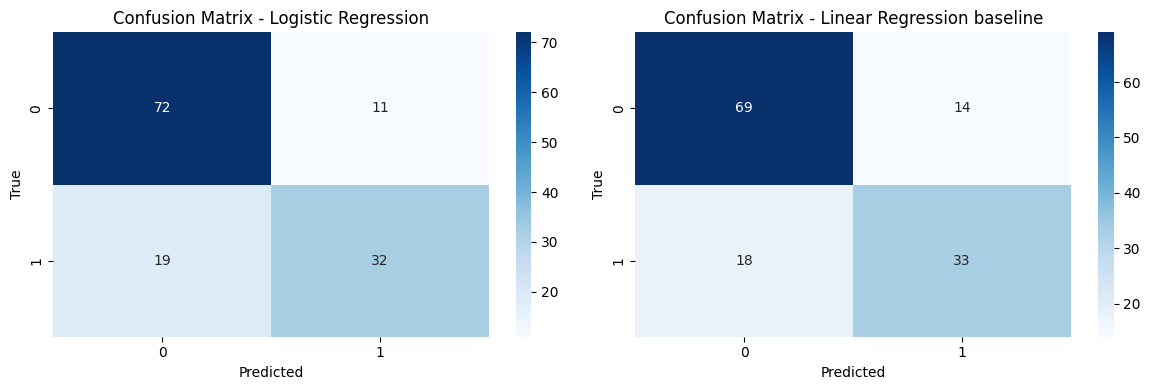

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_linear = confusion_matrix(y_test, y_pred_linear)

sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Linear Regression baseline")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

**Nhận xét Bài 1**

Với bài toán Titanic, `survived` là biến nhị phân nên Logistic Regression phù hợp hơn Linear Regression. Logistic Regression dự đoán trực tiếp xác suất thuộc lớp 1, sau đó dùng ngưỡng 0.5 để phân loại. Cách này đúng bản chất bài toán phân loại hơn.

Linear Regression chỉ phù hợp hơn với bài toán hồi quy, vì đầu ra của nó là giá trị liên tục. Khi dùng Linear Regression cho Titanic, em phải tự ép kết quả về 0 hoặc 1 bằng threshold 0.5. Việc này làm mô hình giống một baseline đơn giản hơn là một mô hình phân loại đúng nghĩa.

Dựa trên các chỉ số Accuracy, Precision, Recall, F1-score và Confusion Matrix, em sẽ ưu tiên Logistic Regression cho bài toán dự đoán sống sót trên Titanic.

# Bài 2 — Dry Bean Dataset

Mục tiêu của phần này là phân loại các loại hạt trong Dry Bean Dataset bằng hai thuật toán:

1. Logistic Regression
2. K-Nearest Neighbors

Em sẽ dùng các feature số của hạt, scale dữ liệu bằng StandardScaler, sau đó so sánh hai mô hình bằng Accuracy, Precision, Recall và F1-score.

Load Dry Bean Dataset

In [18]:
DATA_DIR = Path("Dry_Bean_Dataset")

train_path = DATA_DIR / "dry_bean_train.csv"
test_path = DATA_DIR / "dry_bean_test.csv"
excel_path = DATA_DIR / "Dry_Bean_Dataset.xlsx"

if train_path.exists() and test_path.exists():
    bean_train = pd.read_csv(train_path)
    bean_test = pd.read_csv(test_path)
    print("Đã đọc file train/test CSV có sẵn.")
else:
    print("Chưa có file CSV, đọc từ file Excel và tự chia train/test.")
    
    bean_df = pd.read_excel(excel_path, engine="openpyxl")
    
    bean_df.columns = (
        bean_df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    
    bean_df["class"] = (
        bean_df["class"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    
    bean_df = bean_df.dropna().drop_duplicates().reset_index(drop=True)
    
    X_bean = bean_df.drop(columns=["class"])
    y_bean = bean_df["class"]
    
    X_train_bean, X_test_bean, y_train_bean, y_test_bean = train_test_split(
        X_bean,
        y_bean,
        test_size=0.2,
        random_state=42,
        stratify=y_bean
    )
    
    bean_train = X_train_bean.copy()
    bean_train["class"] = y_train_bean
    
    bean_test = X_test_bean.copy()
    bean_test["class"] = y_test_bean

print("Train shape:", bean_train.shape)
print("Test shape:", bean_test.shape)

display(bean_train.head())

print("\nPhân bố lớp train:")
display(bean_train["class"].value_counts())

print("\nPhân bố lớp test:")
display(bean_test["class"].value_counts())

Chưa có file CSV, đọc từ file Excel và tự chia train/test.
Train shape: (10834, 17)
Test shape: (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
4285,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
3216,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
7254,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
7966,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
5401,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI



Phân bố lớp train:


class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


Phân bố lớp test:


class
DERMASON    709
SIRA        527
SEKER       406
HOROZ       372
CALI        326
BARBUNYA    265
BOMBAY      104
Name: count, dtype: int64

Tách X/y

In [19]:
target = "class"

X_train_bean = bean_train.drop(columns=[target])
y_train_bean = bean_train[target]

X_test_bean = bean_test.drop(columns=[target])
y_test_bean = bean_test[target]

print("X_train_bean:", X_train_bean.shape)
print("X_test_bean:", X_test_bean.shape)

print("\nCác lớp:")
print(sorted(y_train_bean.unique()))

X_train_bean: (10834, 16)
X_test_bean: (2709, 16)

Các lớp:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


Hàm đánh giá mô hình

In [20]:
def evaluate_classifier(model_name, y_true, y_pred, average="macro"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average, zero_division=0)
    recall = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    
    print(model_name)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision_macro": precision,
        "Recall_macro": recall,
        "F1_macro": f1
    }

Logistic Regression cho Dry Bean

In [21]:
bean_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

bean_logistic_model.fit(X_train_bean, y_train_bean)

y_pred_bean_logistic = bean_logistic_model.predict(X_test_bean)

result_bean_logistic = evaluate_classifier(
    "Dry Bean - Logistic Regression",
    y_test_bean,
    y_pred_bean_logistic
)

Dry Bean - Logistic Regression
Accuracy : 0.9192
Precision: 0.9307
Recall   : 0.93
F1-score : 0.9302

Classification report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



KNN cho Dry Bean

In [22]:
bean_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

bean_knn_model.fit(X_train_bean, y_train_bean)

y_pred_bean_knn = bean_knn_model.predict(X_test_bean)

result_bean_knn = evaluate_classifier(
    "Dry Bean - KNN",
    y_test_bean,
    y_pred_bean_knn
)

Dry Bean - KNN
Accuracy : 0.9155
Precision: 0.929
Recall   : 0.9256
F1-score : 0.927

Classification report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



So sánh Logistic Regression và KNN

In [23]:
bean_results = pd.DataFrame([
    result_bean_logistic,
    result_bean_knn
])

display(bean_results)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Dry Bean - Logistic Regression,0.919158,0.930725,0.930049,0.930237
1,Dry Bean - KNN,0.915467,0.928993,0.925628,0.927027


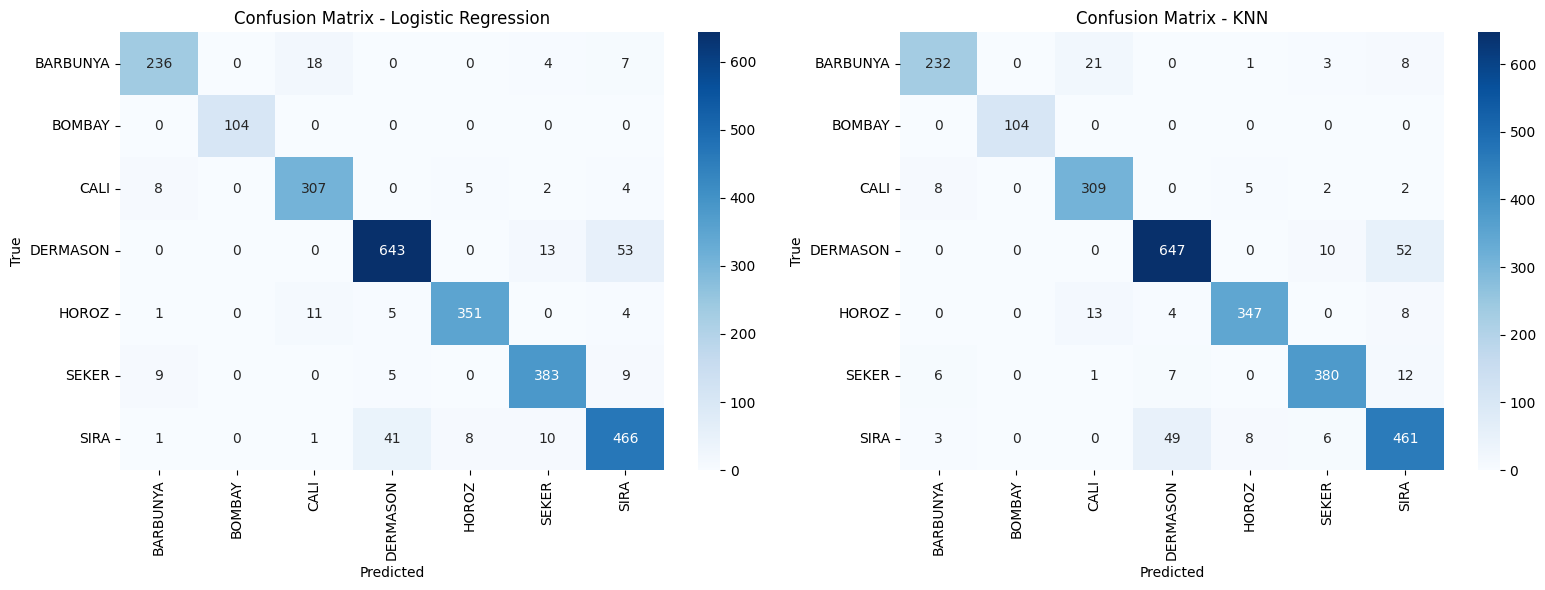

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = sorted(y_test_bean.unique())

cm_lr = confusion_matrix(y_test_bean, y_pred_bean_logistic, labels=labels)
cm_knn = confusion_matrix(y_test_bean, y_pred_bean_knn, labels=labels)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix - KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

**Nhận xét Bài 2**

Cả Logistic Regression và KNN đều cho kết quả khá tốt trên Dry Bean Dataset. Điều này cho thấy các đặc trưng hình dạng của hạt có chứa nhiều thông tin để phân biệt các loại hạt khác nhau.

Logistic Regression là mô hình tuyến tính, học một bộ trọng số để phân biệt các lớp. Ưu điểm của mô hình này là chạy nhanh, dễ triển khai và dễ giải thích hơn. Tuy nhiên, nếu ranh giới giữa các lớp quá phức tạp thì Logistic Regression có thể bị hạn chế.

KNN dự đoán dựa trên các điểm dữ liệu gần nhất. Mô hình này khá trực quan và có thể bắt được quan hệ cục bộ giữa các mẫu. Tuy nhiên KNN phụ thuộc nhiều vào việc scale dữ liệu và có thể chậm hơn khi số lượng mẫu lớn, vì lúc dự đoán cần tính khoảng cách đến nhiều điểm train.

Dựa trên các chỉ số Accuracy, Precision, Recall và F1-score, em sẽ chọn mô hình có F1-score macro cao hơn. Nếu hai mô hình có kết quả gần nhau, em sẽ ưu tiên Logistic Regression vì mô hình nhẹ hơn và dự đoán nhanh hơn.

# Tổng kết chung

Qua bài tập này, em hiểu rõ hơn sự khác nhau giữa bài toán hồi quy và phân loại. Với Titanic, biến mục tiêu `survived` là nhị phân nên Logistic Regression phù hợp hơn Linear Regression. Linear Regression vẫn có thể dùng làm baseline bằng cách threshold đầu ra, nhưng cách này không đúng bản chất bằng Logistic Regression.

Với Dry Bean Dataset, cả Logistic Regression và KNN đều là các mô hình phân loại hợp lý. Logistic Regression phù hợp khi muốn mô hình đơn giản, nhanh và dễ triển khai. KNN phù hợp khi muốn phân loại dựa trên sự gần nhau giữa các mẫu, nhưng cần scale dữ liệu cẩn thận.

Một điểm quan trọng em rút ra là với các mô hình như Logistic Regression và KNN, việc chia train/test đúng cách và chuẩn hóa dữ liệu là rất quan trọng. Nếu scale sai hoặc dùng thông tin từ test trong lúc train, kết quả đánh giá có thể bị lệch và không phản ánh đúng khả năng thực tế của mô hình.